In [31]:
import torch
import torch.nn as nn      # For building neural network models
import torch.optim as optim       # For optimizers in backpropagation
from torch.utils.data import DataLoader, TensorDataset # For handling datasets and creating data loaders
from sklearn.datasets import make_classification # For generating synthetic classification datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler # Z-score normalization
import matplotlib.pyplot as plt

In [32]:
torch.manual_seed(42)  # For reproducibility

#create the dataset
# (symulating 1000 samples, 3 features, all informative meaning they contribute to the target variable, and no redundant features)
X,y = make_classification(n_samples=1000, n_features=3, n_informative=3, n_redundant=0, random_state=42)




In [33]:
# Split the dataset into training 70%, validation 15%, and test 15% sets
X_temp ,X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.176, random_state=42)

In [34]:
# Standardize the features (Z-score normalization)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)



In [35]:
# Convert to PyTorch tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32) # this line converts the training features to a PyTorch tensor of type float32
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1,1) # this line converts the training labels to a PyTorch tensor of type float32 and reshapes it to have one column (i.e., a 2D tensor with shape [num_samples, 1])

X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32).view(-1,1)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).view(-1,1)

# print the shapes of the tensors to verify
X_train_t.shape, y_train_t.shape, X_val_t.shape, y_val_t.shape, X_test_t.shape, y_test_t.shape

(torch.Size([700, 3]),
 torch.Size([700, 1]),
 torch.Size([150, 3]),
 torch.Size([150, 1]),
 torch.Size([150, 3]),
 torch.Size([150, 1]))

In [36]:
# Create TensorDatasets and DataLoaders
# TensorDatasets use to combined features and lables into a single dataset object
train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

# brakes into mini-batches of 32
# dataloaders use to creates an iterable over the dataset with support for batching ,shuffeling and parellel loading
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)



In [37]:
class CustomerPredictor(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden = nn.Linear(3,8)# defines a hidden layer with 3 input features and 8 hidden features
        self.output = nn.Linear(8,1)# defines an output layer with 8 input features (from the hidden layer) 
                                    # and 1 output feature (for binary classification)

    def forward(self, x):
        x = torch.relu(self.hidden(x))  # applies the hidden layer to the input x and 
                                        # then applies the ReLU activation function to introduce non-linearity
        return self.output(x)

model = CustomerPredictor()

In [38]:
loss_fn = nn.BCEWithLogitsLoss() # Binary Cross-Entropy Loss with Logits, suitable for binary classification tasks
optimizer = optim.Adam(model.parameters(), lr=1e-3,weight_decay=1e-4) # Adam optimizer with a learning
# lr(lerning rate) of 0.001 and L2 regularization (weight decay) of 0.0001
# weight decay is used to prevent overfitting by adding a penalty to the loss function based on the magnitude of the model's weights.

# if lr is too low it takes more time to train ,reduce efficiency and may get stuck  
# if lr is too high it may cause the model to diverge and fail to converge to a good solution
# the model is not stable when lr is too high


In [39]:
print(list(model.parameters()))
# 1 st tensor is the weights of the hidden layer, 
# 2nd tensor is the bias of the hidden layer, 
# 3rd tensor is the weights of the output layer,
#  and 4th tensor is the bias of the output layer

[Parameter containing:
tensor([[ 0.4414,  0.4792, -0.1353],
        [ 0.5304, -0.1265,  0.1165],
        [-0.2811,  0.3391,  0.5090],
        [-0.4236,  0.5018,  0.1081],
        [ 0.4266,  0.0782,  0.2784],
        [-0.0815,  0.4451,  0.0853],
        [-0.2695,  0.1472, -0.2660],
        [-0.0677, -0.2345,  0.3830]], requires_grad=True), Parameter containing:
tensor([-0.4557, -0.2662, -0.1630, -0.3471,  0.0545, -0.5702,  0.5214, -0.4904],
       requires_grad=True), Parameter containing:
tensor([[ 0.2730,  0.0588, -0.1148,  0.2185,  0.0551,  0.2857,  0.0387, -0.1115]],
       requires_grad=True), Parameter containing:
tensor([0.0950], requires_grad=True)]


In [40]:
epochs = 50
train_losses = []
val_losses = []
CHECKPOINT_PATH = "best_customer_predictor.pt" # Path to save the model checkpoint
best_val_loss = float('inf') # Initialize best validation loss to infinity

print("Start training...")

for epoch in range(epochs):
    model.train() # Set the model to training mode
    epoch_train_loss = 0.0

    for X_batch, y_batch in train_loader:

        # X_batch and y_batch are the input features and labels for the current batch of training data
        # X_batch has a shape of [batch_size, num_features] 
        # batch_size is the number of samples in the current batch (e.g., 32) 
        # num_features is the number of features in the dataset (e.g., 3)
        # y_batch has a shape of [batch_size, 1]

        optimizer.zero_grad() # Clear the old gradients before the backward pass

        logits = model(X_batch) # Forward pass: compute the model's predictions
        loss = loss_fn(logits, y_batch) # Compute the loss between predictions and true labels

        loss.backward() # Backward pass: calculate gradients

        optimizer.step() # Update the model's parameters based on the computed gradients
        epoch_train_loss += loss.item()  # Accumulate the total training loss

    avg_train_loss = epoch_train_loss / len(train_loader) # Calculate average training loss for the epoch
    train_losses.append(avg_train_loss) # Store the average training loss

    model.eval() # Set the model to evaluation mode

    with torch.no_grad(): # Disable gradient calculation for validation
            val_logits = model(X_val_t) # Forward pass: calculate the model's predictions on the validation set
            val_loss = loss_fn(val_logits, y_val_t) # Calculate the validation loss
    val_losses.append(val_loss.item()) # Store the validation loss


    # Check if this is the best validation loss so far and save the model checkpoint if it is
    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item() # Update the best validation loss
        torch.save(model.state_dict(), CHECKPOINT_PATH)
    # if (epoch + 1) % 10 == 0: # Print training progress every 10 epochs
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {avg_train_loss:.4f}, Val Loss: {val_loss.item():.4f}")
    

Start training...
Epoch 1/50, Train Loss: 0.6677, Val Loss: 0.6591
Epoch 2/50, Train Loss: 0.6525, Val Loss: 0.6417
Epoch 3/50, Train Loss: 0.6368, Val Loss: 0.6234
Epoch 4/50, Train Loss: 0.6192, Val Loss: 0.6030
Epoch 5/50, Train Loss: 0.5994, Val Loss: 0.5800
Epoch 6/50, Train Loss: 0.5765, Val Loss: 0.5555
Epoch 7/50, Train Loss: 0.5528, Val Loss: 0.5284
Epoch 8/50, Train Loss: 0.5273, Val Loss: 0.5015
Epoch 9/50, Train Loss: 0.5016, Val Loss: 0.4743
Epoch 10/50, Train Loss: 0.4754, Val Loss: 0.4481
Epoch 11/50, Train Loss: 0.4499, Val Loss: 0.4232
Epoch 12/50, Train Loss: 0.4256, Val Loss: 0.3990
Epoch 13/50, Train Loss: 0.4015, Val Loss: 0.3766
Epoch 14/50, Train Loss: 0.3795, Val Loss: 0.3560
Epoch 15/50, Train Loss: 0.3587, Val Loss: 0.3373
Epoch 16/50, Train Loss: 0.3391, Val Loss: 0.3208
Epoch 17/50, Train Loss: 0.3224, Val Loss: 0.3059
Epoch 18/50, Train Loss: 0.3060, Val Loss: 0.2931
Epoch 19/50, Train Loss: 0.2926, Val Loss: 0.2822
Epoch 20/50, Train Loss: 0.2800, Val Loss

In [41]:
try:
    ckpt = torch.load(CHECKPOINT_PATH,map_location="cpu",weights_only=True)
    # map_location ="cpu" ensures that the model is loaded on the CPU, 
    # which is important if the checkpoint was saved on a GPU but we want to load it on a machine without a GPU.

    # weights_only=True is used to load only the model's weights (state_dict) from the checkpoint,
    # which is useful when we only want to restore the model's parameters without loading the entire training state 
    # (e.g., optimizer state, epoch number, etc.).
except TypeError:
    ckpt = torch.load(CHECKPOINT_PATH,map_location="cpu")
# says to the model to load the weights from the checkpoint file specified by CHECKPOINT_PATH.
model.load_state_dict(ckpt)
print(f"training Complete! Loaded best checkpoint (val loss{best_val_loss:.4f}) ")

training Complete! Loaded best checkpoint (val loss0.2123) 


In [54]:
from sklearn.metrics import classification_report, confusion_matrix
model.eval()

with torch.no_grad():
    test_logits = model(X_test_t)
    test_loss = loss_fn(test_logits, y_test_t)
 # Apply sigmoid to convert logits to probabilities
    probs = torch.sigmoid(test_logits).numpy().ravel()
# Convert probabilities to binary predictions using a threshold of 0.5
    y_true = y_test_t.cpu().numpy().ravel() 
# ravel() is used to flatten the array of true labels into a 1D array, which is necessary for calculating accuracy.
# y_pred is a binary array where values greater than or equal to 0.5
# are classified as 1 (positive class) and values less than 0.5 are classified as 0 (negative class).
# astype(int) is used to convert the boolean array resulting from the comparison (probs >= 0.5)
#  into an integer array of 0s and 1s, which represents the predicted class labels.
y_pred = (probs >= 0.5).astype(int)

# evaluation metrics
print(f"Test Loss: {test_loss.item():.4f}")
print(classification_report(y_true, y_pred))
print(confusion_matrix(y_true, y_pred))

Test Loss: 0.2163
              precision    recall  f1-score   support

         0.0       0.90      0.90      0.90        81
         1.0       0.88      0.88      0.88        69

    accuracy                           0.89       150
   macro avg       0.89      0.89      0.89       150
weighted avg       0.89      0.89      0.89       150

[[73  8]
 [ 8 61]]


In [ ]:
# inference on new data
new_data = [[1.5, 2.0, 0.8]] # raw features for a new sample,
# which should be in the same scaler as the training data (i.e., 3 features)
new_data_t = torch.tensor(new_data, dtype=torch.float32) # Convert the new data to a PyTorch tensor

model.eval() # Set the model to evaluation mode

with torch.no_grad(): # Disable gradient calculation for inference
    new_logits = model(new_data_t) # Forward pass: calculate the model's prediction for the new data
    
    new_prob = torch.sigmoid(new_logits).item() # Apply sigmoid to get the probability of the positive class
    
    new_pred = int(new_prob >= 0.5) # Convert probability to binary prediction using a threshold of 0.5

print(f"Predicted Probability: {new_prob:.4f}")
print(f"Predicted Class: {new_pred}")

Predicted Probability: 0.9999
Predicted Class: 1


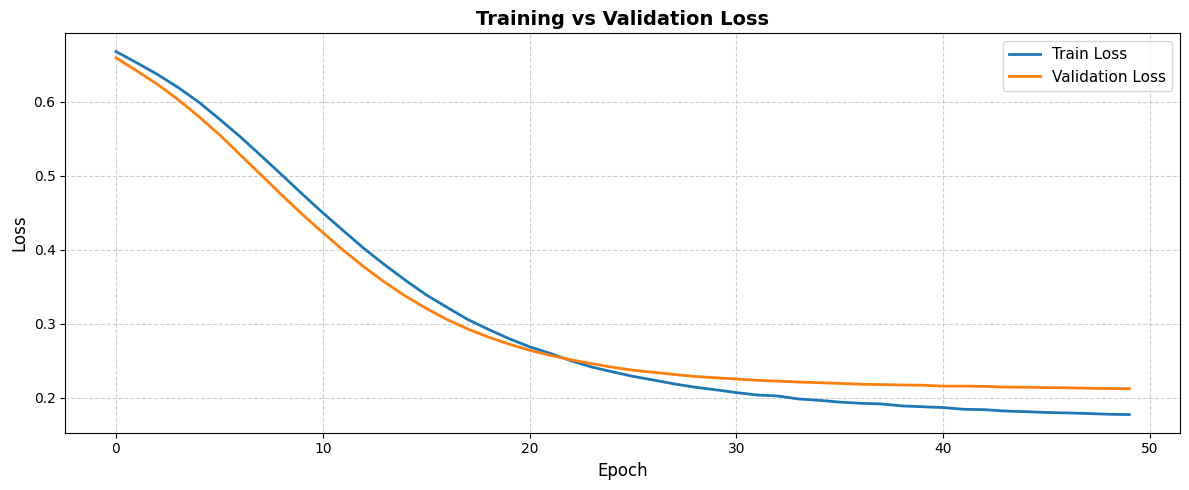

In [73]:

plt.figure(figsize=(12, 5))

plt.plot(train_losses, label='Train Loss', linewidth=2)
plt.plot(val_losses, label='Validation Loss', linewidth=2)

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Training vs Validation Loss', fontsize=14, fontweight='bold')

plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()